# Libraries

In [50]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns


# Data Understanding

<table style="width:50%; font-size:12px; border-collapse: collapse; margin: 0 auto; text-align: left;">
  <thead>
    <tr style="background-color:#f2f2f2; text-align:left; color: black;">
      <th style="border:1px solid #ddd;">Attribute</th>
      <th style="border:1px solid #ddd;">Description</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="border:1px solid #ddd;">carID</td><td style="border:1px solid #ddd;">An attribute that contains an identifier for each car</td></tr>
    <tr><td style="border:1px solid #ddd;">Brand</td><td style="border:1px solid #ddd;">The car’s main brand (e.g. Ford, Toyota)</td></tr>
    <tr><td style="border:1px solid #ddd;">model</td><td style="border:1px solid #ddd;">The car model</td></tr>
    <tr><td style="border:1px solid #ddd;">year</td><td style="border:1px solid #ddd;">The year of Registration of the Car</td></tr>
    <tr><td style="border:1px solid #ddd;">mileage</td><td style="border:1px solid #ddd;">The total reported distance travelled by the car (in miles)</td></tr>
    <tr><td style="border:1px solid #ddd;">tax</td><td style="border:1px solid #ddd;">The amount of road tax (in £) that, in 2020, was applicable to the car in question.</td></tr>
    <tr><td style="border:1px solid #ddd;">fuelType</td><td style="border:1px solid #ddd;">Type of Fuel used by the car (Diesel, Petrol, Hybrid, Electric)</td></tr>
    <tr><td style="border:1px solid #ddd;">mpg</td><td style="border:1px solid #ddd;">Average Miles per Gallon</td></tr>
    <tr><td style="border:1px solid #ddd;">engineSize</td><td style="border:1px solid #ddd;">Size of Engine in liters (Cubic Decimeters)</td></tr>
    <tr><td style="border:1px solid #ddd;">paintQuality%</td><td style="border:1px solid #ddd;">The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation)</td></tr>
    <tr><td style="border:1px solid #ddd;">previousOwners</td><td style="border:1px solid #ddd;">Number of previous registered owners of the vehicle</td></tr>
    <tr><td style="border:1px solid #ddd;">hasDamage</td><td style="border:1px solid #ddd;">Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not</td></tr>
    <tr><td style="border:1px solid #ddd;">price</td><td style="border:1px solid #ddd;">The car’s price when purchased by Cars 4 You (in £)</td></tr>
  </tbody>
</table>


## Train

In [51]:
train_cars = pd.read_csv("data/train.csv")
print(f"The train dataset has {train_cars.shape[0]} rows and {train_cars.shape[1]} columns")

The train dataset has 75973 rows and 14 columns


In [52]:
metric_features_train = train_cars.select_dtypes(include=['number']).columns
non_metric_features_train = train_cars.columns.drop(metric_features_train).to_list()

In [53]:
train_cars.head()

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


In [54]:
train_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


In [55]:
train_cars.duplicated().sum()

0

In [56]:
train_cars.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
carID,75973.0,NaN,NaN,NaN,37986.0,21931.660338,0.0,18993.0,37986.0,56979.0,75972.0
Brand,74452,72,Ford,14808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,74456,735,Focus,6353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,74482.0,NaN,NaN,NaN,2017.096611,2.208704,1970.0,2016.0,2017.0,2019.0,2024.121759
price,75973.0,NaN,NaN,NaN,16881.889553,9736.926322,450.0,10200.0,14699.0,20950.0,159999.0
transmission,74451,40,Manual,38050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,74510.0,NaN,NaN,NaN,23004.184088,22129.788366,-58540.574478,7423.25,17300.0,32427.5,323000.0
fuelType,74462,34,Petrol,37995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,68069.0,NaN,NaN,NaN,120.329078,65.521176,-91.12163,125.0,145.0,145.0,580.0
mpg,68047.0,NaN,NaN,NaN,55.152666,16.497837,-43.421768,46.3,54.3,62.8,470.8


## Test

In [57]:
test_cars = pd.read_csv("data/test.csv")
print(f"The test dataset has {test_cars.shape[0]} rows and {test_cars.shape[1]} columns")

The test dataset has 32567 rows and 13 columns


In [58]:
metric_features_test = test_cars.select_dtypes(include=['number']).columns
non_metric_features_test = test_cars.columns.drop(metric_features_test).to_list()

In [59]:
test_cars.head()

,carID,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,89856,Hyundai,I30,2022.878006,Automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,0.0
1,106581,VW,Tiguan,2017.000000,Semi-Auto,-48190.655673,Petrol,150.0,38.2,2.0,60.0,2.0,0.0
2,80886,BMW,2 Series,2016.000000,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2.0,0.0
3,100174,Opel,Grandland X,2019.000000,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1.0,0.0
4,81376,BMW,1 Series,2019.000000,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4.0,0.0


In [60]:
test_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32567 entries, 0 to 32566
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           32567 non-null  int64  
 1   Brand           31918 non-null  object 
 2   model           31917 non-null  object 
 3   year            31914 non-null  float64
 4   transmission    31944 non-null  object 
 5   mileage         31878 non-null  float64
 6   fuelType        31911 non-null  object 
 7   tax             29259 non-null  float64
 8   mpg             29279 non-null  float64
 9   engineSize      31939 non-null  float64
 10  paintQuality%   31942 non-null  float64
 11  previousOwners  31970 non-null  float64
 12  hasDamage       31970 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 3.2+ MB


In [61]:
test_cars.duplicated().sum()

0

In [62]:
test_cars.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
carID,32567.0,NaN,NaN,NaN,92256.0,9401.427445,75973.0,84114.5,92256.0,100397.5,108539.0
Brand,31918,64,Ford,6360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,31917,593,Focus,2721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,31914.0,NaN,NaN,NaN,2017.102299,2.207969,1991.0,2016.0,2017.0,2019.0,2024.121759
transmission,31944,38,Manual,16312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,31878.0,NaN,NaN,NaN,22952.658921,22132.758713,-58540.574478,7298.25,17225.5,32500.0,279000.0
fuelType,31911,29,Petrol,16113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,29259.0,NaN,NaN,NaN,120.569239,65.56057,-91.12163,125.0,145.0,145.0,580.0
mpg,29279.0,NaN,NaN,NaN,55.210728,17.644635,-43.421768,46.3,54.3,62.8,470.8
engineSize,31939.0,NaN,NaN,NaN,1.665377,0.574467,-0.103493,1.2,1.6,2.0,6.6


# Data Preparation

In [66]:
def column_treatment(df):
    df = df.copy()
    df.columns = [col.strip().lower().replace("%", "percent")for col in df.columns]

    return df

In [67]:
train_cars = column_treatment(train_cars)
test_cars = column_treatment(test_cars)

In [68]:
def convert_to_int(df, cols):
    df = df.copy()
    df[cols] = df[cols].fillna(0).astype(int)
    return df


In [69]:
cols = ["year", "previousowners", "hasdamage"]

train_cars = convert_to_int(train_cars, cols)
test_cars = convert_to_int(test_cars, cols)

In [70]:
train_cars

,carid,brand,model,year,price,transmission,mileage,fueltype,tax,mpg,enginesize,paintqualitypercent,previousowners,hasdamage
0,69512,VW,Golf,2016,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4,0
1,53000,Toyota,Yaris,2019,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1,0
2,6366,Audi,Q2,2019,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4,0
3,29021,Ford,FIESTA,2018,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2,0
4,10062,BMW,2 Series,2019,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,37194,Mercedes,C Class,2015,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0,0
75969,6265,Audi,Q3,2013,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2,0
75970,54886,Toyota,Aygo,2017,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3,0
75971,860,Audi,Q3,2015,12990,Manual,69072.0,iesel,125.0,60.100000,2.0,74.0,2,0


## Data Inconsistency Fixes

### Filtering Positive Values and Cars with Maximum Year 2020

In [ ]:
year_sup20_train = (train_cars["year"] > 2020).sum()
year_sup20_test = (test_cars["year"] > 2020).sum()

print(f"Train: {year_sup20_train} | Test: {year_sup20_test} rows where year > 2020")

train_cars = train_cars[train_cars["year"] <=2020].reset_index(drop=True)
test_cars = test_cars[test_cars["year"] <=2020].reset_index(drop=True)

Train: 358 | Test: 180 rows where year > 2020


In [16]:
train_cars = train_cars[(train_cars[metric_features_train] >= 0).all(axis=1) & (train_cars["year"] <=2020)].reset_index(drop=True)
test_cars = test_cars[(test_cars[metric_features_test] >= 0).all(axis=1) & (test_cars["year"] <=2020)].reset_index(drop=True)

print(f"Train: {train_cars.shape[0]} | Test: {test_cars.shape[0]} rows")

Train: 57803 | Test: 24937 rows


In [213]:
train_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57803 entries, 0 to 57802
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           57803 non-null  int64  
 1   Brand           56652 non-null  object 
 2   model           56648 non-null  object 
 3   year            57803 non-null  float64
 4   price           57803 non-null  int64  
 5   transmission    56613 non-null  object 
 6   mileage         57803 non-null  float64
 7   fuelType        56651 non-null  object 
 8   tax             57803 non-null  float64
 9   mpg             57803 non-null  float64
 10  engineSize      57803 non-null  float64
 11  paintQuality%   57803 non-null  float64
 12  previousOwners  57803 non-null  float64
 13  hasDamage       57803 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 6.2+ MB


In [214]:
test_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24937 entries, 0 to 24936
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           24937 non-null  int64  
 1   Brand           24442 non-null  object 
 2   model           24445 non-null  object 
 3   year            24937 non-null  float64
 4   transmission    24466 non-null  object 
 5   mileage         24937 non-null  float64
 6   fuelType        24422 non-null  object 
 7   tax             24937 non-null  float64
 8   mpg             24937 non-null  float64
 9   engineSize      24937 non-null  float64
 10  paintQuality%   24937 non-null  float64
 11  previousOwners  24937 non-null  float64
 12  hasDamage       24937 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 2.5+ MB


### Descriptive Statistics

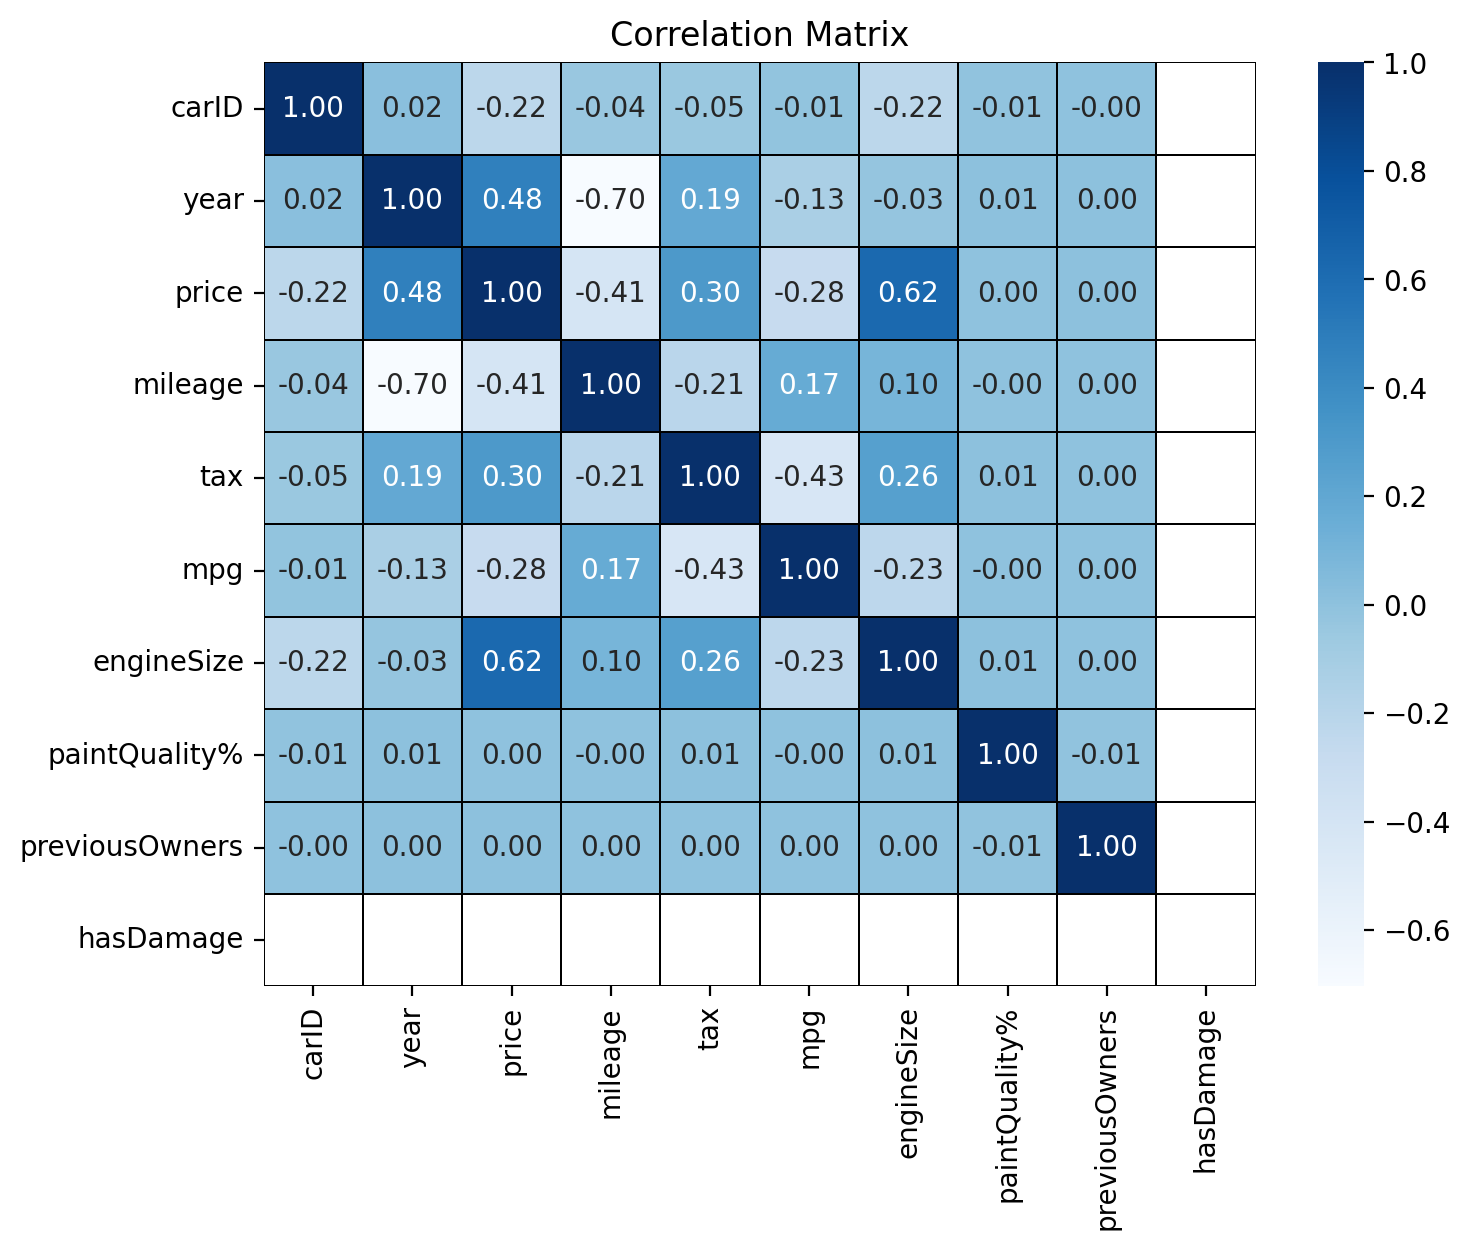

In [215]:
corr = train_cars[metric_features_train].corr()

plt.figure(figsize=(8,6),dpi=200)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", linecolor = "black", linewidths=0.01)
plt.title("Correlation Matrix")
plt.show()

#### Outlier Detection

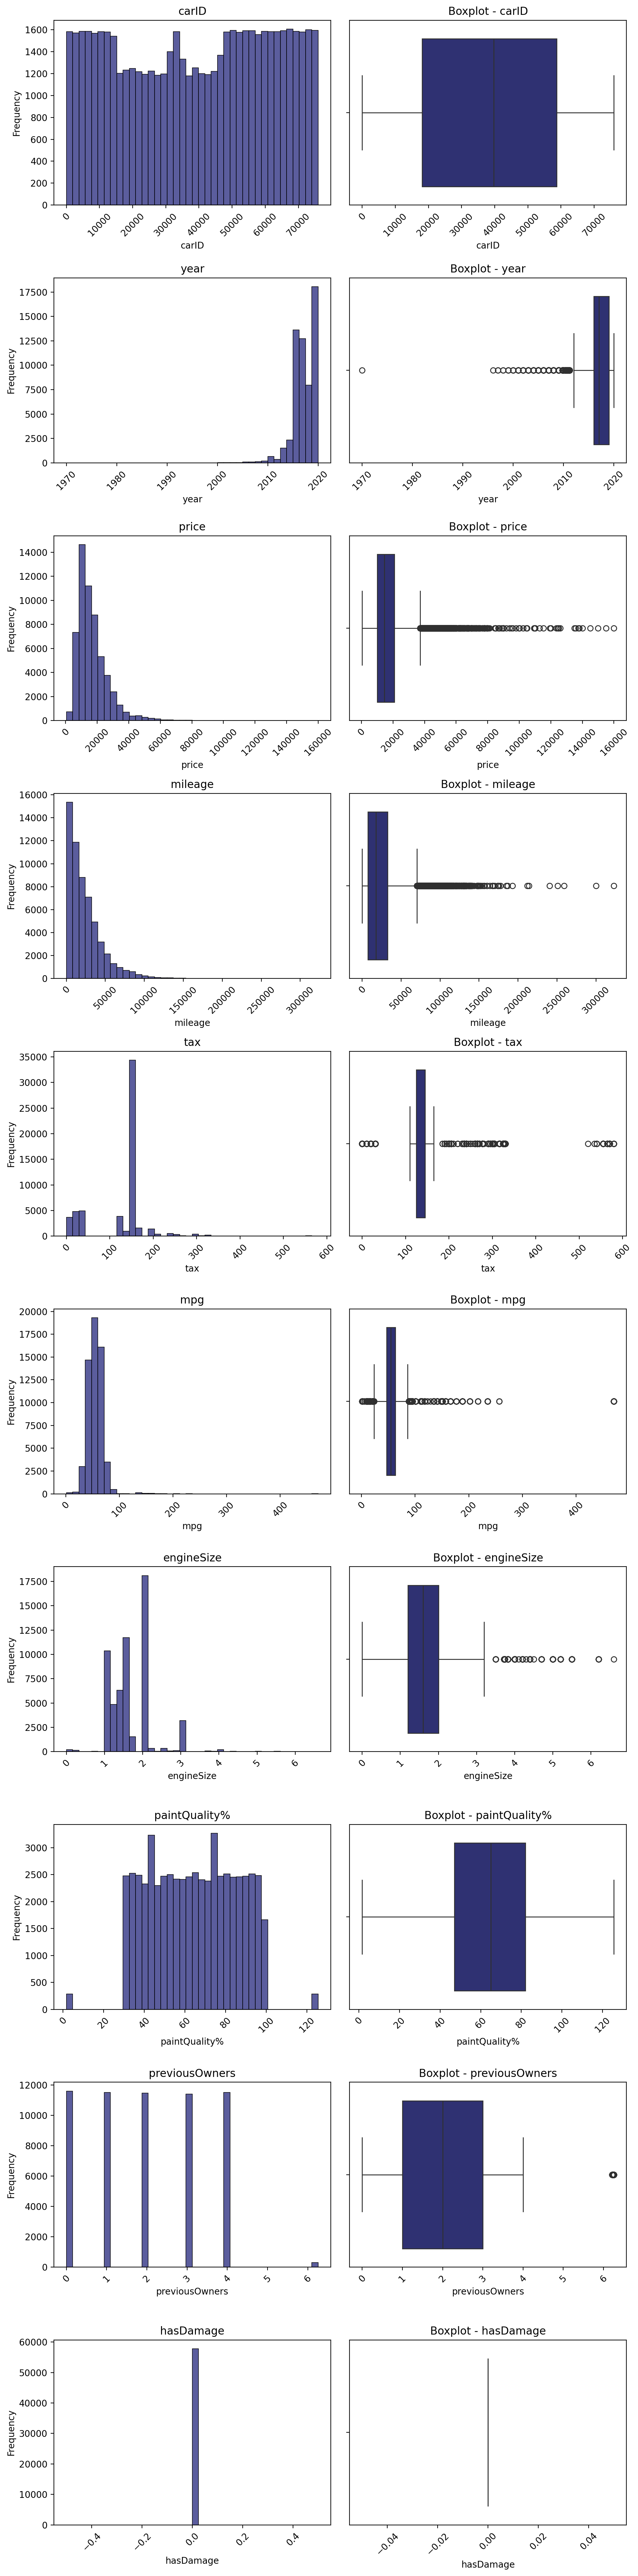

In [ ]:
n_rows_subplot = len(metric_features_train)
n_cols_subplot = 2

fig, axes = plt.subplots(n_rows_subplot, n_cols_subplot, figsize=(10, 4 * n_rows_subplot), dpi=200)

for i, col in enumerate(metric_features_train):    
    sns.histplot(train_cars[col], kde=False, bins=40, color="#24277D", ax=axes[i][0])
    axes[i][0].set_title(f"{col}")
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel("Frequency")
    axes[i][0].tick_params(axis="x", rotation=45)

    
    sns.boxplot(x=train_cars[col], color="#24277D", ax=axes[i][1])
    axes[i][1].set_title(f"Boxplot - {col}")
    axes[i][1].set_xlabel(col)
    axes[i][1].set_ylabel("")
    axes[i][1].tick_params(axis="x", rotation=45)


plt.tight_layout()
plt.show()

In [218]:
def outliers_dataframe(df, numeric_cols):    
    outliers_df = pd.DataFrame(index=df.index)
    pct_outliers = pd.Series(index=numeric_cols, dtype=float)

    for col in numeric_cols:
        data = df[col]
        Q1 = np.percentile(data, 25)
        Q3 = np.percentile(data, 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # Colocar NaN se não for outlier
        outliers_df[col] = data.where((data < lower) | (data > upper), np.nan)
        
        # Percentagem de outliers
        pct_outliers[col] = outliers_df[col].count() / len(df) * 100

    return outliers_df, pct_outliers

In [173]:
df_outliers_train, pct_outliers_train = outliers_dataframe(train_cars, metric_features_train)
print(pct_outliers_train)  

carID              0.000000
year               2.171168
price              3.681470
mileage            4.214314
tax               25.792779
mpg                1.006868
engineSize         0.814837
paintQuality%      0.000000
previousOwners     0.000000
hasDamage          0.000000
dtype: float64


In [175]:
df_outliers_train.describe().T

,count,mean,std,min,25%,50%,75%,max
carID,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,1255.0,2008.752988,2.683375,1970.000000,2008.0000,2010.00000,2010.00,2011.0
price,2128.0,49494.342105,13297.178394,37236.000000,40991.0000,45997.00000,53500.00,159999.0
mileage,2436.0,89828.376045,19637.016299,70230.000000,77000.0000,84000.00000,96774.75,323000.0
tax,14909.0,79.233104,101.442796,0.000000,20.0000,30.00000,30.00,580.0
mpg,582.0,65.356613,38.475932,11.417268,20.7455,88.32164,94.10,117.7
engineSize,471.0,4.232166,0.569987,3.500000,4.0000,4.00000,4.40,6.6
paintQuality%,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previousOwners,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hasDamage,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Missing Values

In [ ]:
def fill_missing_values(df, non_metric_features):
    for i in non_metric_features:
        df[i] = df[i].fillna("unknown")
        
    return df

In [146]:
train_cars = fill_missing_values(train_cars, non_metric_features_train)
test_cars = fill_missing_values(test_cars, non_metric_features_test)

print(f"Train: {train_cars.isna().sum().sum()} | Test: {test_cars.isna().sum().sum()} missing values")

Train: 0 | Test: 0 missing values


### Data Type and String Cleaning 

In [147]:
def convert_to_int(df, cols):
    df = df.copy()
    df[cols] = df[cols].astype(int)
    return df

In [148]:
cols = ["year", "previousOwners", "hasDamage"]

train_cars = convert_to_int(train_cars, cols)
test_cars = convert_to_int(test_cars, cols)

In [149]:
brand_mapping= {
        #ford
        "or":"ford", "for":"ford", "ord":"ford",
        #vw
        "w":"vw", "v":"vw",
        #opel
        "ope":"opel", "pel":"opel", "pe":"opel",
        #mercedes
        "ercedes":"mercedes", "mercede":"mercedes", "ercede":"mercedes",
        #bmw
        "bm":"bmw", "mw":"bmw",
        #audi
        "udi":"audi", "aud":"audi", "ud":"audi",
        #toyota
        "oyota":"toyota", "toyot":"toyota",
        #skoda
        "skod":"skoda", "kod":"skoda", "koda":"skoda",
        #hyundai
        "yundai":"hyundai", "hyunda":"hyundai", "yunda":"hyundai"
}

transmission_mapping= {
    #manual
    "anual":"manual", "manua":"manual", "anua":"manual",
    #semi-auto
    "semi-aut":"semi-auto", "emi-auto":"semi-auto", "emi-aut":"semi-auto",
    #automatic
    "automati":"automatic", "utomatic":"automatic", "utomati":"automatic", "automati":"automatic",
    #unknown
    "unknow":"unknown", "nknown":"unknown", "nknow":"unknown", "nknow":"unknown", 
}

fuel_mapping= {
    #petrol
    "petro":"petrol", "etrol":"petrol", "etro":"petrol", 
    #diesel
    "iesel":"diesel", "diese":"diesel", "iese":"diesel",
    #hybrid
    "hybri":"hybrid", "ybrid":"hybrid",
    #other
    "othe":"other", "ther":"other"
} 

def string_cleaning(df, non_metric_features):
    df = df.copy()
    
    mappings = {'Brand': brand_mapping,'transmission': transmission_mapping,'fuelType': fuel_mapping}

    df[non_metric_features] = df[non_metric_features].apply(lambda x: x.str.lower().str.replace(' ', ''))
    
    for col, mapping in mappings.items():
        df[col] = df[col].apply(lambda x: mapping.get(x, x))
    
    return df

In [150]:
train_cars = string_cleaning(train_cars, non_metric_features_train)
test_cars = string_cleaning(test_cars, non_metric_features_test)

### Problematic Values

In [ ]:
brand_model_mean = train_cars[train_cars["engineSize"] != 0].groupby(["Brand", "model"])["engineSize"].mean()

def fill_engine_size(group, mean_bm = brand_model_mean):
    non_zero_values = group[group != 0].unique()

    if len(non_zero_values) > 0:
        group = group.replace(0, non_zero_values[0])
    
    else:
        brand, model = group.name[0], group.name[1]
        if (brand, model) in mean_bm:
            group = group.replace(0, mean_bm[(brand, model)])
                   
    return group

train_cars["engineSize"] = train_cars.groupby(["Brand", "model", "year"])["engineSize"].transform(fill_engine_size)
test_cars["engineSize"] = test_cars.groupby(["Brand", "model", "year"])["engineSize"].transform(fill_engine_size)

In [153]:
train_cars[train_cars["engineSize"] == 0]

# 2.5 L (≈ 2.5) — o modelo C230 de 2007 tem cilindrada de 2 496 cc (≈ 2.5 L) para o motor a gasolina
# 0.647 L (≈ 0.65) — se for o modelo BMW i3 com Range Extender, o motor a combustão tem 647 cc

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
23588,37949,mercedes,230,2007,4500,automatic,94000.0,petrol,520.0,29.4,0.0,80.0,2,0
39027,14512,bmw,i,2017,19000,automatic,23983.0,hybrid,0.0,470.8,0.0,95.0,4,0


In [154]:
train_cars.describe()

,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,57803.000000,57803.000000,57803.000000,57803.000000,57803.000000,57803.000000,57803.000000,57803.000000,57803.000000,57803.0
mean,38727.667059,2017.056969,16816.520769,23349.974293,121.147573,55.266104,1.667068,64.613687,2.014965,0.0
std,22641.975324,2.156932,9890.304445,21545.799344,64.281966,16.544699,0.564830,21.063726,1.441200,0.0
min,0.000000,1970.000000,450.000000,1.000000,0.000000,1.100000,0.000000,1.638913,0.000000,0.0
25%,18099.500000,2016.000000,9999.000000,7500.000000,125.000000,47.000000,1.200000,47.000000,1.000000,0.0
50%,39692.000000,2017.000000,14495.000000,17600.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,58705.500000,2019.000000,20890.000000,32591.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75971.000000,2020.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.000000,0.0


In [155]:
train_cars[train_cars["paintQuality%"] == train_cars["paintQuality%"].max()]

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
198,53403,toyota,aygo,2016,7995,manual,25300.0,other,0.0,69.0,1.0,125.594308,1,0
2234,54228,toyota,gt86,2017,18495,semi-auto,13930.0,petrol,150.0,39.8,2.0,125.594308,1,0
2540,53219,toyota,c-hr,2017,19698,automatic,21890.0,hybrid,135.0,74.3,1.8,125.594308,0,0
6216,51202,toyota,corolla,2010,24995,automatic,3989.0,hybrid,135.0,57.7,1.8,125.594308,0,0
7034,52871,toyota,ayg,2018,6450,manual,14619.0,petrol,145.0,69.0,1.0,125.594308,0,0
8196,52471,toyota,aygo,2018,8489,manual,12493.0,petrol,145.0,56.5,1.0,125.594308,0,0
10073,53320,toyota,yaris,2012,5481,manual,26285.0,petrol,125.0,51.4,1.3,125.594308,3,0
11178,55455,toyota,unknown,2017,15200,manual,47026.0,diesel,125.0,60.1,2.0,125.594308,1,0
17398,54677,toyota,yaris,2014,5499,manual,66575.0,petrol,125.0,52.3,1.3,125.594308,2,0
19231,52016,toyota,aygo,2018,8195,manual,20205.0,petrol,145.0,68.9,1.0,125.594308,0,0


In [156]:
train_cars["paintQuality%"] = train_cars["paintQuality%"].clip(upper=100)
test_cars["paintQuality%"] = test_cars["paintQuality%"].clip(upper=100)

In [157]:
train_cars[(train_cars["tax"] == 0) & (train_cars["fuelType"] != "electric")]

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
22,55065,toyota,c-hr,2017,15490,automatic,59000.0,hybrid,0.0,74.3,1.8,95.0,2,0
50,54783,toyota,yaris,2014,10490,automatic,34528.0,hybrid,0.0,80.7,1.5,79.0,1,0
56,19051,ford,fiesta,2013,6500,manual,43181.0,petrol,0.0,65.7,1.0,88.0,0,0
57,18960,ford,fiesta,2015,5991,manual,61292.0,petrol,0.0,65.7,1.0,31.0,2,0
95,15550,ford,fiesta,2016,9500,manual,14879.0,petrol,0.0,65.7,1.0,97.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57718,54268,toyota,aygo,2017,6620,manual,10266.0,petrol,0.0,69.0,1.0,51.0,0,0
57724,52992,toyota,aygo,2016,8550,manual,20680.0,petrol,0.0,69.0,1.0,66.0,2,0
57731,30535,ford,fiesta,2016,8990,manual,46000.0,other,0.0,65.7,1.0,88.0,2,0
57780,65725,vw,golf,2016,18500,automatic,30000.0,other,0.0,188.3,1.4,53.0,1,0


In [ ]:
bmyf_tax_mode = train_cars[train_cars["tax"] != 0].groupby(["Brand", "model","year","fuelType"])["tax"].agg(lambda x: x.mode().iloc[0]).to_dict()

brand_fuel_tax_mode = train_cars[train_cars["tax"] != 0].groupby(["Brand","fuelType"])["tax"].agg(lambda x: x.mode().iloc[0]).to_dict()

fuel_mean = train_cars[train_cars["tax"] != 0].groupby(["fuelType"])["tax"].mean()

def fill_tax(row, mean_bmy=bmyf_tax_mode, mean_b=brand_fuel_tax_mode, mean_fuel=fuel_mean):
    if row["tax"] != 0 or row["fuelType"] == "electric" :
        return row["tax"]
    
    key_specific = (row["Brand"], row["model"], row["year"], row["fuelType"])
    key_general = (row["Brand"], row["fuelType"])

    if key_specific in mean_bmy:
        return mean_bmy[key_specific]
    elif key_general in mean_b:
        return mean_b[key_general]
    else:
        return mean_fuel[row["fuelType"]]
        

train_cars["tax"] = train_cars.apply(fill_tax, axis=1)
test_cars["tax"] = test_cars.apply(fill_tax, axis=1)

In [159]:
train_cars[(train_cars["mpg"] < 10) | (train_cars["mpg"] > 120)]

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
192,71321,vw,golf,2017,22000,automatic,28385.0,hybrid,135.0,156.90000,1.400000,49.0,3,0
260,10299,bmw,4series,2019,24250,semi-auto,10125.0,diesel,145.0,151.04181,2.000000,90.0,3,0
407,53577,toyota,prius,2018,19072,automatic,43584.0,hybrid,135.0,235.00000,2.781776,54.0,1,0
419,7479,bmw,3series,2016,14795,automatic,70250.0,hybrid,135.0,134.50000,2.000000,77.0,0,0
452,42361,mercedes,cclass,2016,17500,semi-auto,41758.0,hybrid,135.0,134.50000,2.000000,52.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57261,39749,mercedes,cclass,2016,16341,automatic,61225.0,hybrid,135.0,134.50000,2.000000,81.0,0,0
57500,9823,bmw,3series,2016,14399,automatic,68458.0,hybrid,135.0,148.70000,2.000000,50.0,2,0
57560,10966,bmw,5series,2019,30450,semi-auto,10191.0,hybrid,135.0,156.90000,2.000000,63.0,0,0
57582,51885,toyota,prius,2014,15995,automatic,47221.0,hybrid,135.0,134.50000,1.800000,74.0,3,0


In [ ]:
mpg_mean_by_group = train_cars[(train_cars["mpg"] >= 10) & (train_cars["mpg"] <= 120)].groupby(["Brand", "fuelType"])["mpg"].mean().to_dict()
mpg_fuel_mean = train_cars[(train_cars["mpg"] >= 10) & (train_cars["mpg"] <= 120)].groupby("fuelType")["mpg"].mean().to_dict()

def replace_mpg_values(df, mpg_mean_dict, mpg_fuel_mean, min_value=10, max_value=120):
    df = df.copy()

    value_idx = df[(df["mpg"] < min_value) | (df["mpg"] > max_value)].index

    for idx in value_idx:
        brand = df.at[idx, "Brand"]
        fuel = df.at[idx, "fuelType"]
        key = (brand, fuel)

        if key in mpg_mean_dict:
            df.at[idx,"mpg"] = mpg_mean_dict[key]
        else:
            df.at[idx,"mpg"] = mpg_fuel_mean[fuel]
            
    return df

In [164]:
train_cars = replace_mpg_values(train_cars, mpg_mean_by_group, mpg_fuel_mean)
test_cars = replace_mpg_values(test_cars, mpg_mean_by_group, mpg_fuel_mean)

# Features

## Dealing with Features

### Categorical

In [ ]:
le_brand = LabelEncoder()

train_cars["Brand_encoded"] = le_brand.fit_transform(train_cars["Brand"])
test_cars["Brand_encoded"] = le_brand.transform(test_cars["Brand"])

array(['toyota', 'audi', 'bmw', 'skoda', 'vw', 'ford', 'opel', 'mercedes',
       'hyundai', 'unknown'], dtype=object)

In [ ]:
top_models = train_cars["model"].value_counts().nlargest(20).index
train_cars["model_grouped"] = train_cars["model"].where(train_cars["model"].isin(top_models), "Other")
test_cars["model_grouped"] = test_cars["model"].where(test_cars["model"].isin(top_models), "Other")

train_cars = pd.get_dummies(train_cars, columns=["model_grouped"], drop_first=True)
test_cars = pd.get_dummies(test_cars, columns=["model_grouped"], drop_first=True)

In [ ]:
train_cars["fuelType_grouped"] = train_cars["fuelType"].replace({"hybrid":"hybrid/electric","electric":"hybrid/electric"})
train_cars["fuelType_grouped"] = train_cars["fuelType_grouped"].where(train_cars["fuelType_grouped"].isin(["hybrid/electric","petrol","diesel"]), "other")

train_cars = pd.get_dummies(train_cars, columns=["fuelType_grouped"], drop_first=True)
test_cars = pd.get_dummies(test_cars, columns=["fuelType_grouped"], drop_first=True)

array(['petrol', 'diesel', 'hybrid', 'other', 'electric'], dtype=object)

In [ ]:
train_cars = pd.get_dummies(train_cars, columns=["transmission"], drop_first=True)
test_cars = pd.get_dummies(test_cars, columns=["transmission"], drop_first=True)

## Feature Engenering

In [ ]:
def create_features(df):  
    df = df.copy()

    df["carAge"] = 2020 - df["year"]
    df["recentModel"] = df["recentModel"] = (train_cars["year"] >= 2018).astype(int)

    #eficiencia do motor
    df["mpg_per_engine"] = df["mpg"] / (df["engineSize"] + 1e-5)
    df["carAge_x_mileage"] = df["carAge"] * df["mileage"]

    df["isHybridOrElectric"] = df["fuelType"].isin(["Hybrid", "Electric"]).astype(int)

    return df

###  Data Scaling

In [ ]:

scaler = StandardScaler()
train_cars_ss = train_cars.copy()
train_cars_ss[metric_features_test] = scaler.fit_transform(train_cars_ss[metric_features_test])

test_cars[metric_features_test] = scaler.transform(test_cars[metric_features_test])